# Signal Research — does L1 book imbalance predict forward returns?

**What "signal research" is:** before building or tuning any strategy, you ask a
narrower, cheaper question — *does this feature carry predictive information about
future price?* You measure it directly with the **information coefficient (IC)** =
correlation between the signal now and the return over the next *h* seconds. No
strategy, no fills, no PnL yet — just "is there signal here at all."

The loop, run inline in a notebook (this *is* the quant workflow — not a dashboard):

1. Load market data, construct a candidate signal
2. Measure predictiveness: **IC across horizons** (the decay curve)
3. Does it *sort* returns? — **decile monotonicity**
4. Is it *real*? — **out-of-sample stability** across days & instruments
5. The honest part: **IC ≠ profit** — does it survive fees + spread?

**Candidate signal:** L1 book imbalance
`imb = (bid_qty − ask_qty) / (bid_qty + ask_qty) ∈ [−1, 1]`.
Intuition: more resting size on the bid than the ask = net buying pressure → price
should tick up. **Data:** Hyperliquid ETH/SOL, 3 days of canon (2026-05-05/06/07).

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '/home/jseow/code/bpt-core/bpt-canon/python')
import bpt_canon as bc
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr

CANON_DIR = '/tmp/hurst_canon'      # local 3-day canon: hl-2026-05-0{5,6,7}.canon
ETH, SOL = 1002, 1003

def make_bars(b, iid, bar='1s'):
    """BBO frame -> clean -> fixed-grid bars of mid + L1 book imbalance."""
    b = b[b.instrument_id == iid]
    b = b[(b.bid>0)&(b.ask>0)&(b.ask>=b.bid)&(b.bid_qty>0)&(b.ask_qty>0)].copy()
    b['mid'] = (b.bid + b.ask) / 2
    b['imb'] = (b.bid_qty - b.ask_qty) / (b.bid_qty + b.ask_qty)
    b['ts'] = pd.to_datetime(b.ts_ns, unit='ns')
    b = b.set_index('ts').sort_index()
    return pd.DataFrame({'mid': b.mid.resample(bar).last(),
                         'imb': b.imb.resample(bar).last()}).ffill().dropna()

def load_bars(path, iid, bar='1s'):
    return make_bars(bc.read_bbos(path), iid, bar)

bars = load_bars(f'{CANON_DIR}/hl-2026-05-07.canon', ETH)
print(f'ETH 2026-05-07: {len(bars):,} one-second bars')
bars.head()

ETH 2026-05-07: 86,405 one-second bars


,mid,imb
ts,,
2026-05-07 00:40:30,2340.55,-0.389765
2026-05-07 00:40:31,2340.55,-0.997732
2026-05-07 00:40:32,2340.55,-0.707115
2026-05-07 00:40:33,2340.45,-0.671342
2026-05-07 00:40:34,2340.45,-0.518096


## 1. The signal

`imb ∈ [−1, 1]`: −1 = all size on the ask (sellers stacked), +1 = all on the bid,
0 = balanced. First just look at it — a signal that's always ~0 or always saturated
carries little information to sort on.

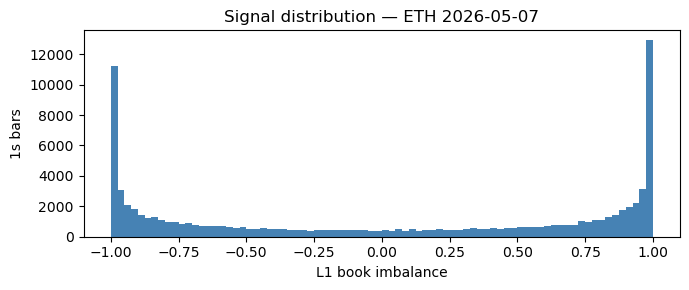

mean=+0.032  std=0.793


In [2]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(bars.imb, bins=80, color='steelblue', edgecolor='none')
ax.set_xlabel('L1 book imbalance'); ax.set_ylabel('1s bars')
ax.set_title('Signal distribution — ETH 2026-05-07')
plt.tight_layout(); plt.show()
print(f'mean={bars.imb.mean():+.3f}  std={bars.imb.std():.3f}')

## 2. Predictiveness — IC across horizons

The **information coefficient**: correlation between `imb` now and the log-return over
the next *h* seconds. Pearson (linear) + Spearman (rank, robust to outliers). A real
signal is strongest at short horizons and **decays** as the edge mean-reverts away.
No look-ahead: signal at *t*, return from *t* → *t+h*.

,horizon_s,pearson_IC,spearman_IC
0,1,0.3274,0.4865
1,2,0.3347,0.4934
2,5,0.3138,0.4440
3,10,0.2755,0.3664
4,30,0.1641,0.1962
5,60,0.1083,0.1214


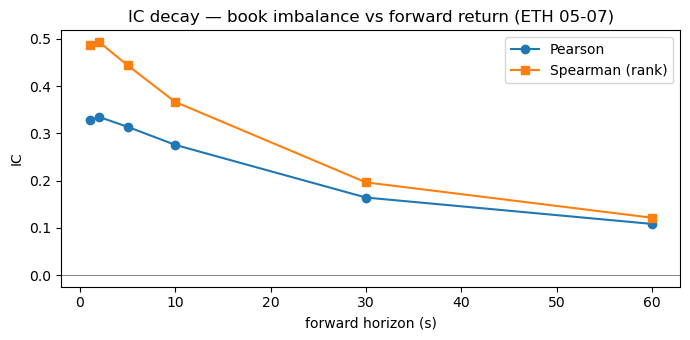

In [3]:
logmid = np.log(bars.mid.values)
horizons = [1, 2, 5, 10, 30, 60]
rows = []
for h in horizons:
    fwd = np.full(len(bars), np.nan); fwd[:-h] = logmid[h:] - logmid[:-h]
    s = bars.imb.values; m = ~np.isnan(fwd)
    rows.append((h, np.corrcoef(s[m], fwd[m])[0, 1], spearmanr(s[m], fwd[m]).statistic))
ic = pd.DataFrame(rows, columns=['horizon_s', 'pearson_IC', 'spearman_IC'])
display(ic.round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ic.horizon_s, ic.pearson_IC, 'o-', label='Pearson')
ax.plot(ic.horizon_s, ic.spearman_IC, 's-', label='Spearman (rank)')
ax.axhline(0, color='grey', lw=.7)
ax.set_xlabel('forward horizon (s)'); ax.set_ylabel('IC')
ax.set_title('IC decay — book imbalance vs forward return (ETH 05-07)'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Does it *sort* returns? — decile monotonicity

IC is one number and can be inflated by outliers. The sharper test: bucket bars into
deciles of `imb` and look at the **mean forward return per decile**. A real directional
signal makes a **monotonic staircase** — most ask-heavy bucket → most negative forward
return, most bid-heavy → most positive.

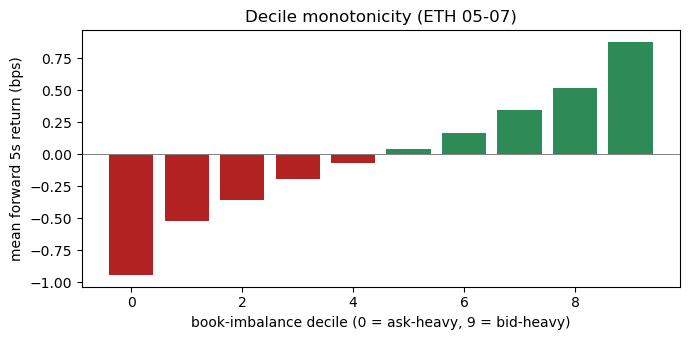

spread  d9 − d0 = 1.82 bps


In [4]:
h = 5
fwd = np.full(len(bars), np.nan); fwd[:-h] = logmid[h:] - logmid[:-h]
d = pd.DataFrame({'imb': bars.imb.values, 'fwd': fwd}).dropna()
d['decile'] = pd.qcut(d.imb, 10, labels=False, duplicates='drop')
g = d.groupby('decile').fwd.mean() * 1e4   # bps

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(g.index, g.values, color=['firebrick' if v < 0 else 'seagreen' for v in g.values])
ax.axhline(0, color='grey', lw=.7)
ax.set_xlabel('book-imbalance decile (0 = ask-heavy, 9 = bid-heavy)')
ax.set_ylabel('mean forward 5s return (bps)')
ax.set_title('Decile monotonicity (ETH 05-07)')
plt.tight_layout(); plt.show()
print(f'spread  d9 − d0 = {g.iloc[-1] - g.iloc[0]:.2f} bps')

## 4. Is it *real*? — out-of-sample stability

The trap that killed the Hurst study: a signal can look great on one day and flip sign
the next. A real signal holds its **sign and rough magnitude across days and
instruments**. Recompute the 5s Spearman IC for ETH and SOL across all three days.

In [5]:
def ic_of(bb, h=5):
    lm = np.log(bb.mid.values)
    fwd = np.full(len(bb), np.nan); fwd[:-h] = lm[h:] - lm[:-h]
    m = ~np.isnan(fwd)
    return spearmanr(bb.imb.values[m], fwd[m]).statistic

res = {}
for day in ['2026-05-05', '2026-05-06', '2026-05-07']:
    raw = bc.read_bbos(f'{CANON_DIR}/hl-{day}.canon')   # read each canon once
    res[day] = {'ETH': ic_of(make_bars(raw, ETH)), 'SOL': ic_of(make_bars(raw, SOL))}
grid = pd.DataFrame(res).T   # rows = days, cols = instruments
print('5s Spearman IC by (day, instrument):')
display(grid.round(4))
print('All positive, same order of magnitude => stable, real signal.')
print('(Contrast: the Hurst regime study FLIPPED sign across these same days.)')

5s Spearman IC by (day, instrument):


,ETH,SOL
2026-05-05,0.4495,0.4188
2026-05-06,0.4351,0.3839
2026-05-07,0.4440,0.3454


All positive, same order of magnitude => stable, real signal.
(Contrast: the Hurst regime study FLIPPED sign across these same days.)


## 5. The honest part — IC ≠ profit

Book imbalance is a **real** signal: strong short-horizon IC, clean monotonic deciles,
stable across days and instruments. That does **not** make it tradeable:

- **Magnitude.** The d9 − d0 spread is ~2 bps over 5s. Crypto-perp **taker fees alone
  are ~2-5 bps round-trip** — naive taker execution eats the whole edge.
- **Decay.** IC roughly halves by 10s — you must act in **seconds**, so it's only
  exploitable as a **maker** (skew your quote, don't cross the spread), not a taker.
- This is exactly where most signals die: **statistically real, economically marginal**
  once costs are in.

**So the next step is NOT another feature** — it's a **cost-aware test**: does using
imbalance to *skew the AS quote* (a maker action, no taker fee) convert this IC into PnL
after fees? That's a backtester job, with the DSR/OOS discipline.

Signal research told us **there's something here, and where**. Only a cost-aware
backtest tells us if it's **money**. That one experiment — imbalance-skewed AS quoting —
is the concrete next thing worth running.